#

# Nemotron Korea — 5대 소비가치 선호 분포 전체 파이프라인

```
STEP 0  공통 설정       임포트 / 경로 / 모델 / 앵커 정의
STEP 1  culinary 임계값 1000건 샘플 → Percentile 5/95 → 스케일러 초기화
STEP 2  hobby 포화도    유니크 취미 증가율 추적 → 전량 추출
STEP 3  hobby 라벨링    OpenAI Batch API
STEP 4  hobby 맵 구축   임베딩 + pkl 저장 → Google Drive 업로드
STEP 5  최적 가중치     10000건  KMeans Silhouette
STEP 6  실제 생성   청크 처리 → 체크포인트 → Google Drive 자동 업로드
STEP 7  군집 분류       사전 정의 군집 중심점 → 코사인 유사도 Top-2 매칭 → CSV
```

---
## STEP 0. 공통 설정

In [3]:
import ast
import json
import math
import os
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
from datasets import load_dataset
from openai import OpenAI
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from sentence_transformers import SentenceTransformer, util
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import userdata
key = userdata.get('apikey')

# ── OpenAI 설정 ───────────────────────────────────────────────────────────────
OPENAI_API_KEY = key   # ← 실제 키로 교체

SecretNotFoundError: Secret apikey does not exist.

구글 드라이브 업로드용 중요X

In [13]:
# =========================================================
# Google Colab + PyDrive2 완전 동작 예제
# =========================================================

!pip -q install PyDrive2

from pathlib import Path
from google.colab import auth
from oauth2client.client import GoogleCredentials
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

# =========================================================
# 1. Google 인증
# =========================================================

auth.authenticate_user()

gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()

drive = GoogleDrive(gauth)

print("Google Drive 인증 완료")


# =========================================================
# 2. Drive 폴더 찾기 / 생성
# =========================================================

def get_or_create_gdrive_folder(
    drive: GoogleDrive,
    folder_name: str
) -> str:
    """
    Google Drive에서 폴더를 찾거나 생성 후 folder_id 반환
    """

    query = (
        f"title='{folder_name}' and "
        "mimeType='application/vnd.google-apps.folder' and "
        "trashed=false"
    )

    results = drive.ListFile({'q': query}).GetList()

    if results:
        folder_id = results[0]['id']
        print(f"[기존 폴더 사용] {folder_name}")
    else:
        folder = drive.CreateFile({
            'title': folder_name,
            'mimeType': 'application/vnd.google-apps.folder'
        })

        folder.Upload()
        folder_id = folder['id']

        print(f"[새 폴더 생성] {folder_name}")

    return folder_id


# =========================================================
# 3. 파일 업로드
# =========================================================

def upload_to_gdrive(
    local_path: Path,
    folder_id: str,
    drive: GoogleDrive,
    make_public: bool = True
) -> str:
    """
    로컬 파일을 Google Drive에 업로드

    - 동일 파일명 존재 시 덮어쓰기
    - 공유 링크 반환
    """

    if not local_path.exists():
        raise FileNotFoundError(local_path)

    filename = local_path.name

    # 동일 파일 검색
    query = (
        f"title='{filename}' and "
        f"'{folder_id}' in parents and "
        "trashed=false"
    )

    existing = drive.ListFile({'q': query}).GetList()

    # 덮어쓰기 or 신규 생성
    if existing:
        gfile = drive.CreateFile({'id': existing[0]['id']})
        print(f"[덮어쓰기] {filename}")
    else:
        gfile = drive.CreateFile({
            'title': filename,
            'parents': [{'id': folder_id}]
        })
        print(f"[신규 업로드] {filename}")

    # 파일 업로드
    gfile.SetContentFile(str(local_path))
    gfile.Upload()

    # 공개 링크 설정
    if make_public:
        gfile.InsertPermission({
            'type': 'anyone',
            'value': 'anyone',
            'role': 'reader'
        })

    # 공유 URL
    url = f"https://drive.google.com/file/d/{gfile['id']}/view"

    print(f"업로드 완료: {url}")

    return url


# =========================================================
# 4. 사용할 Drive 폴더명
# =========================================================

GDRIVE_FOLDER_NAME = "colab_uploads"

# 폴더 확보
GDRIVE_FOLDER_ID = get_or_create_gdrive_folder(
    drive,
    GDRIVE_FOLDER_NAME
)

print("Folder ID:", GDRIVE_FOLDER_ID)


# =========================================================
# 5. 테스트 파일 생성
# =========================================================

test_file = Path("/content/test.txt")

test_file.write_text(
    "Hello Google Drive from Colab!",
    encoding="utf-8"
)

print("테스트 파일 생성 완료")


# =========================================================
# 6. 업로드 실행
# =========================================================

drive_url = upload_to_gdrive(
    local_path=test_file,
    folder_id=GDRIVE_FOLDER_ID,
    drive=drive
)

print("공유 링크:")
print(drive_url)

Google Drive 인증 완료
[기존 폴더 사용] colab_uploads
Folder ID: 1GNKpSPtO41t8zUbzWiEdCBSofIyhFVah
테스트 파일 생성 완료
[덮어쓰기] test.txt
업로드 완료: https://drive.google.com/file/d/1A-7kKXxsbe4Bs0EDAXkGpGGLD_E9LYlY/view
공유 링크:
https://drive.google.com/file/d/1A-7kKXxsbe4Bs0EDAXkGpGGLD_E9LYlY/view


In [19]:
# ── 로컬 경로 (중간 작업용) ───────────────────────────────────────────────────
CSV_PATH       = Path("/content/drive/MyDrive/data/sampled_nemotron_personas_10k.csv")# ─
LOCAL_DIR      = Path("outputs")
CHECKPOINT_DIR = LOCAL_DIR / "checkpoints"
LOCAL_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

BATCH_JSONL_PATH = LOCAL_DIR / "hobby_batch_requests.jsonl"
HOBBY_RESULT_CSV = LOCAL_DIR / "hobby_value_scores.csv"
HOBBY_MAP_PKL    = LOCAL_DIR / "hobby_value_map.pkl"
PROGRESS_FILE    = CHECKPOINT_DIR / "progress.json"
FINAL_PARQUET    = LOCAL_DIR / "nemotron_value_scores_1M.parquet"

# ── Google Drive 설정 ─────────────────────────────────────────────────────────
# Drive 내 저장할 폴더 이름 (없으면 자동 생성)
GDRIVE_FOLDER_NAME = "nemotron_value_pipeline"


# OpenAI Batch API 제한
BATCH_MAX_REQUESTS = 1000
BATCH_MAX_TOKENS = 1_000_000
TOKENS_PER_REQUEST = 1000

# ── 공통 하이퍼파라미터 ──────────────────────────────────────────────────────
EMBED_MODEL_NAME    = "jhgan/ko-sroberta-multitask"
VALUE_COLS          = ["functional", "emotional", "social", "epistemic", "ethical"]
N_THRESHOLD_SAMPLES = 10_00
N_HOBBY_SCAN_MAX    = 10_000
N_WEIGHT_SEARCH     = 50_00
FINAL_BATCH_SIZE    = 512
SIM_THRESHOLD = 0.6
CHUNK_SIZE          = 10_000

# ── 모델 로드 ────────────────────────────────────────────────────────────────
print(f"임베딩 모델 로드: {EMBED_MODEL_NAME}")
embed_model = SentenceTransformer(EMBED_MODEL_NAME)
print("완료")

임베딩 모델 로드: jhgan/ko-sroberta-multitask


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


완료


In [9]:
# ── CSV 로드 ─────────────────────────────────────────────────────────────────
print(f"CSV 로드: {CSV_PATH}")
df_raw = pd.read_csv(CSV_PATH)

# 컬럼명 통일 (파이프라인 내부에서 사용하는 키로 rename)
#   uuid                     → persona_id
#   hobby_and_interests_list → hobbies_and_interests_list
df_raw = df_raw.rename(columns={
    "uuid":                     "persona_id",
    "hobby_and_interests_list": "hobbies_and_interests_list"
})

print(f"  행 수  : {len(df_raw):,}건")
print(f"  컬럼   : {list(df_raw.columns)}")
print()
print(df_raw.head(2).to_string())


CSV 로드: /content/drive/MyDrive/data/sampled_nemotron_personas_10k.csv
  행 수  : 8,042건
  컬럼   : ['persona_id', 'archetype', 'age', 'persona', 'culinary_persona', 'hobbies_and_interests_list']

                         persona_id  archetype  age                                                                              persona                                                                                                                        culinary_persona                                                       hobbies_and_interests_list
0  f7c1309120bf4762b0ceb29e842ebe51          0   24               윤정호 씨는 제주시에서 무직 상태로 생활하며 고도비만과 불안증을 겪고 있지만, 스포츠와 로컬 맛집에 정통한 24세 청년입니다.   윤정호 씨는 일주일에 대여섯 번은 밖에서 식사를 해결하며, 특히 지글지글 익어가는 흑돼지 근고기나 육즙 가득한 고기 요리에 집착합니다. 2차로는 항상 단골 주점을 찾아가 가벼운 안주에 소주 한 잔을 곁들이며 하루의 불안을 잠재우려 합니다.  ['제주시 흑돼지 맛집 단독 탐방', 'KBL 농구 경기 관전 및 분석', '해안도로 산책과 인디 음악 감상', '동네 사우나에서 휴식하기']
1  fc96d55750ff46d59259974507062620          0   27  김지은 씨는 상실의 아픔을 딛고 아이와 함께할 작은 일식집을 꿈꾸며, 주방의 완벽주의

---
## STEP 1. culinary 소비태그 추출

각 가치별 앵커문장

In [14]:
CULINARY_ANCHORS = {
    "functional": [
        "식비를 최대한 아끼고 가격 대비 성능이나 양이 훌륭한 저렴한 식당이나 가성비 좋은 백반집을 선호한다.",
        "사 먹거나 배달시키는 비용이 아까워서 웬만하면 시장이나 마트에서 장을 봐서 집에서 직접 요리를 해 먹는다.",
        "끼니는 배를 채우고 에너지를 얻기 위한 수단일 뿐이므로 빠르고 간편하게 때울 수 있는 실용적인 식사를 원한다.",
        "편의점 도시락이나 냉동식품처럼 조리 시간이 거의 없고 가격도 저렴한 간편식을 자주 활용한다.",
        "외식보다 도시락을 직접 싸는 편이 비용과 시간 모두 절약되기 때문에 주로 도시락을 준비해 다닌다.",
        "안상식 씨는 일주일에 한 번 가족들과 함께 동네 단골 한우집에서 육즙 가득한 갈비를 굽거나, 가끔은 기름진 짜장면과 탕수육이 생각나 중식당을 찾습니다.",
        "최연옥 씨는 주 5회 이상 배달 앱으로 주문하는 정갈한 카이센동이나 초밥으로 저녁을 해결하며, 외식을 할 때는 고기가 들어가지 않은 나물 정식이나 청국장 같은 한식당을 찾아 건강한 맛을 챙깁니다.",
        "유현 씨는 일주일에 한 번 가족들과 함께 정갈한 나물 반찬과 찌개가 나오는 한식당을 찾아 건강한 한 끼를 나눕니다.",
        "김영걸 씨는 일주일에 대여섯 번은 밖에서 식사를 해결하며 주로 짬뽕 같은 중식이나 고기가 들어가지 않은 한식 메뉴를 찾고, 퇴근길에는 물금읍 시장에서 갓 튀긴 꽈배기를 사 먹는 소소한 버릇이 있습니다.",
        "김정하 씨는 일주일에 대여섯 번은 집 밖에서 식사를 해결하며, 특히 정갈하게 나오는 초밥이나 사시미를 파는 동네 일식집에서 하이볼 한 잔을 곁들이는 시간을 가장 아낍니다.",
        "김정우 씨는 일주일에 대여섯 번이나 외식을 하며 주로 마포구의 오래된 돼지갈비 집이나 깔끔한 초밥 전문점을 방문하고, 식사 후에는 반드시 단골 카페에서 진한 믹스커피 한 잔으로 마무리합니다.",
        "박명순 씨는 명절마다 온 가족이 모여 먹을 꼬막무침과 각종 산나물을 정갈하게 무쳐내며 가족들의 입맛을 책임지는 주방의 절대 권력자입니다.",
        "이금자 씨는 구수한 된장찌개와 쌉싸름한 나물 무침으로 정갈한 한식 상차림을 차려내는 손맛이 매우 뛰어납니다.",
        "성은경 씨는 제철 나물을 데치고 무쳐내는 밑반찬 솜씨가 일품이며, 외식할 때는 자극적이지 않은 정갈한 일식집이나 나물 중심의 한식당을 찾습니다.",
        "남삼례 씨는 정자동 카페거리의 단골 빵집에서 갓 구운 시큼한 사워도우 빵을 골라 집으로 돌아오는 길을 가장 좋아합니다.",
        "김성민 씨는 주 5일 이상 외식을 하며 주로 천안 시내의 한우 전문점에서 두툼한 갈빗살을 굽거나 깔끔한 일식집에서 초밥을 즐깁니다.",
        "최영남 씨는 삭힌 젓갈과 직접 무친 나물로 밥상을 가득 채워 손주들의 입맛을 사로잡는 전라도 손맛의 달인입니다.",
        "김옥순 씨는 대대로 내려오는 비법으로 진한 된장과 고추장을 직접 담그며, 가끔 손주들과 함께 외식하러 나가면 일식집의 뜨끈하고 시원한 우동 국물을 즐깁니다.",
        "김세원 씨는 일주일에 대여섯 번은 배달 앱으로 BHC 뿌링클이나 굽네치킨을 시켜 먹고, 외식을 할 때는 어머니와 함께 청국장이나 보리밥 같은 정갈한 한식당을 즐겨 찾습니다.",
        "김재성 씨는 송파구 일대의 돈카츠와 라멘 맛집 리스트를 꿰고 있으며, 일주일에 한 번 배달 음식을 시킬 때 실패하지 않기 위해 최신 리뷰를 집요하게 분석합니다.",
        "정태영 씨는 집에서 요리하는 번거로움 대신 주 5일 가까이 밖에서 식사를 해결하며, 고기류보다는 나물 비빔밥이나 청국장 같은 담백한 한식을 즐기고 후식으로는 갓 구운 소금빵의 고소한 풍미를 찾는 것에 진심입니다.",
        "신은수 씨는 2주에 한 번 정도 정갈한 나물 반찬과 된장찌개가 나오는 한정식집을 찾아 식사하며, 주말 저녁에는 배달 앱으로 성수동의 유명 베이커리에서 구운 소금빵이나 치아바타를 주문해 먹습니다.",
    ],
    "emotional": [
        "힘든 하루를 보낸 나를 위해 매콤하거나 달콤하고 맛있는 음식을 먹으며 스트레스를 풀고 기분을 전환한다.",
        "맛있는 음식을 먹는 순간이 인생의 가장 큰 행복이며 미식 자체에서 깊은 만족감과 감정적 위안을 얻는다.",
        "단순히 음식 맛뿐만 아니라 식당의 아늑한 인테리어, 좋은 음악, 분위기를 즐기며 힐링하는 것을 좋아한다.",
        "어릴 때 자주 먹던 음식이나 고향의 맛을 떠올리게 하는 메뉴를 먹으며 따뜻한 향수와 감성에 젖는다.",
        "전기태 씨는 일주일에 한 번 배달 짜장면과 탕수육을 시켜 먹는 날을 손꼽아 기다리며, 2주에 한 번은 아내와 함께 동네 고깃집에서 지글지글 구운 삼겹살에 소주 한 잔을 곁들입니다.",
        "김준수 씨는 매일 시내 단골 돈가스 집에서 혼자 밥을 먹으며 그날의 스트레스를 조용히 털어내고, 주말에는 유튜브 레시피를 참고해 생크림과 베이컨을 듬뿍 넣은 크림 파스타를 직접 만들어 보는 소소한 요리 취미가 있습니다.",
        "설숙자 씨는 외식보다는 주 2~3회 집에서 편하게 시켜 먹는 분식이나 김밥 같은 간단한 배달 음식을 통해 일상의 해방감을 느낍니다.",
        "장수철 씨는 일주일에 한 번쯤 정갈한 나물 정식이나 초밥 같은 일식당에서 외식을 하며, 또 한 번은 편리하게 배달 음식을 시켜 먹으며 별미를 즐깁니다.",
        "박현식 씨는 일주일에 두세 번 연남동 일대의 일식 돈카츠 전문점을 찾아 바삭한 튀김 옷의 식감을 즐기거나, 정갈한 나물 반찬이 나오는 한식당에서 식사합니다.",
        "홍희자 씨는 일주일에 네 번 이상 외식을 하며, 주로 고기 없는 나물 반찬이 정갈하게 나오는 한식당을 찾습니다.",
        "박호철 씨는 주말이면 식구들과 함께 원주 식객들이 찾는 순두부찌개나 청국장 집에서 정갈한 한식 식사를 하고, 저녁에는 무실동 단골집에서 모둠전과 소주를 곁들이며 하루의 피로를 씻어냅니다.",
        "김충조 씨는 일주일에 두세 번 단골 돼지갈비집을 찾아 친구들과 시시콜콜한 세상 이야기를 나누며 육즙 가득한 고기를 즐깁니다.",
        "배주경 씨는 제철 나물을 무쳐 밥상을 차리는 솜씨가 일품이며, 일주일에 한 번 배달시키는 짜장면과 탕수육은 일주일 중 가장 기다려지는 작은 사치입니다.",
        "김강 씨는 퇴근길에 동네 빵집에 들러 갓 구운 소금빵을 사 들고 가 아내와 나누어 먹는 소소한 행복을 누립니다.",
        "김송애 씨는 동작구 골목마다 숨어 있는 단골 일식집에서 신선한 초밥 세트를 주문해 천천히 음미하며 미식의 즐거움을 누립니다.",
        "원상희 씨는 만안구 골목의 단골 고깃집에서 삼겹살에 소주 한 잔을 곁들여 하루의 피로를 씻어내며, 가끔은 정갈하게 차려진 일식 돈카츠나 초밥으로 기분을 전환합니다.",
        "박용호 씨는 일주일에 대여섯 번은 가족들과 함께 흑돼지 구이나 갈치조림 같은 한식당을 방문하고, 늦은 밤에는 치킨이나 족발을 배달시켜 먹는 식습관을 가지고 있습니다.",
        "송순근 씨는 일주일에 네 번 이상 외식을 하며 목동 인근의 유명 짬뽕집에서 얼큰한 국물을 즐기거나 나물 정식이 잘 나오는 한정식집을 방문합니다.",
        "김찬민 씨는 업장에서는 정교한 양식 요리를 만들어냈지만, 정작 본인은 주 2~3회 고깃집에서 구워 먹는 한식이나 간편한 피자와 버거를 즐겨 먹습니다.",
        "최도성 씨는 부천역 인근의 오래된 노포 중식당들을 찾아다니며 짬뽕 국물의 농도와 불향의 정도를 세밀하게 비교 분석하는 미식가적인 면모를 보입니다.",
        "김규태 씨는 일주일에 한 번 아내와 함께 수정구 단골 고깃집에서 지글거리는 삼겹살에 소주 한 잔을 곁들이며 일주일의 스트레스를 씻어냅니다.",
        "김종현 씨는 보름에 한 번꼴로 아내와 함께 수원 갈비집에서 육즙 가득한 소갈비를 구워 먹으며 외식의 즐거움을 만끽하고, 평소에는 집에서 편하게 분식집 떡볶이와 바삭한 모둠 튀김을 배달시켜 먹는 소소한 식도락을 즐깁니다.",
        "오우주 씨는 일주일에 5번 이상 외식을 하며, 정갈한 산채비빔밥 같은 한식을 즐기다가도 갑자기 도미노피자나 맘스터치 버거 같은 기름진 패스트푸드로 입가심을 하는 식성을 보입니다."
    ],
    "social": [
        "회사 동료들과 함께 식사하며 소통하거나 비즈니스 미팅 및 회식 자리를 통해 조직 내 유대 관계를 유지한다.",
        "가족, 친구, 연인 등 소중한 사람들과 맛있는 음식을 나누며 대화하고 즐거운 시간을 보내는 모임을 중시한다.",
        "주변 사람들이나 소셜 미디어(SNS)에서 요즘 핫하다고 인정받는 식당에 동참하여 트렌드와 유행에 뒤처지지 않으려 한다.",
        "인스타그램이나 틱톡에 음식 사진을 올려 공감과 반응을 받는 것이 외식 경험의 중요한 일부다.",
        "안상식 씨는 일주일에 한 번 가족들과 함께 동네 단골 한우집에서 육즙 가득한 갈비를 굽거나, 가끔은 기름진 짜장면과 탕수육이 생각나 중식당을 찾습니다.",
        "윤종원 씨는 일주일에 두세 번 부모님과 함께 숯불 향 가득한 돼지갈비나 정갈한 한식당을 찾아 가족 식사를 하며 행복을 느낍니다.",
        "김옥순 씨는 대대로 내려오는 비법으로 진한 된장과 고추장을 직접 담그며, 가끔 손주들과 함께 외식하러 나가면 일식집의 뜨끈하고 시원한 우동 국물을 즐깁니다.",
        "이복례 씨는 제철 나물을 무치고 정갈한 돼지갈비찜을 올리는 집밥에 자신감이 있지만, 주 4회 이상은 자녀와 함께 동네 김밥집이나 고깃집에서 외식을 하며 소소한 대화를 나눕니다.",
        "장수철 씨는 일주일에 한 번쯤 정갈한 나물 정식이나 초밥 같은 일식당에서 외식을 하며, 또 한 번은 편리하게 배달 음식을 시켜 먹으며 별미를 즐깁니다. 특히 횡성한우 거리 근처 식당에서 친구들과 소주잔을 기울이며 옛이야기를 나누는 시간을 인생의 큰 낙으로 꼽습니다.",
        "박명순 씨는 명절마다 온 가족이 모여 먹을 꼬막무침과 각종 산나물을 정갈하게 무쳐내며 가족들의 입맛을 책임지는 주방의 절대 권력자입니다.",
        "박호철 씨는 주말이면 식구들과 함께 원주 식객들이 찾는 순두부찌개나 청국장 집에서 정갈한 한식 식사를 하고, 배달 음식의 간편함보다는 직접 식당에 나가 사람들과 부대끼며 식사하는 분위기를 즐깁니다.",
        "김충조 씨는 일주일에 두세 번 단골 돼지갈비집을 찾아 친구들과 시시콜콜한 세상 이야기를 나누며 육즙 가득한 고기를 즐깁니다.",
        "최동현 씨는 2주에 한 번쯤 동료들과 세종시 내의 두툼한 삼겹살집에서 회식을 하며 스트레스를 풀고, 혼자 있는 날에는 정갈한 사케동이나 돈카츠 같은 일식 배달 음식으로 한 끼를 해결합니다.",
        "강영자 씨는 일주일에 한 번 친구들과 함께 지글지글 익는 돼지갈비를 먹으며 수다를 떨고, 주말이면 동네 빵집에서 갓 구운 단팥빵과 크림빵을 잔뜩 사서 이웃들에게 나누어 줍니다.",
        "김종수 씨는 일주일에 대여섯 번은 집 밖에서 식사를 하며, 특히 가족들과 함께 동네 단골 돼지갈비집에서 고기를 구워 먹는 시간을 가장 행복해합니다.",
        "박병남 씨는 주 2~3회 정도 식당을 찾으며, 특히 매콤한 갈치조림이나 꼬막무침 같은 고기 외의 한식 메뉴를 즐겨 먹습니다. 식사 후에는 반드시 단골 주점에서 시원한 맥주나 소주를 곁들이며 사람들과의 관계를 다집니다.",
        "서안진 씨는 일주일에 두세 번 집 근처 돼지갈비집에서 가족과 외식을 하고, 가끔은 친구들과 단골 주점에 모여 안주를 곁들이며 밀린 이야기를 나눕니다.",
        "권인수 씨는 일주일에 대여섯 번은 외식을 하며, 특히 노량진 근처의 단골 일식집에서 친구들과 사케를 곁들인 모둠 초밥을 먹거나 고기가 들어가지 않은 깔끔한 한정식 차림을 즐겨 찾습니다.",
        "김상영 씨는 일주일에 네다섯 번은 집 밖에서 식사를 해결하며, 직접 식당에 가서 사람들과 얼굴을 맞대고 식사하는 분위기를 중요하게 생각합니다.",
        "유주현 씨는 일주일에 다섯 번 정도 퇴근 후 동료들과 의정부 중앙시장 근처 고깃집에서 삼겹살에 소주 한 잔을 곁들이며 하루의 스트레스를 씻어냅니다.",
        "장지영 씨는 주 5회 이상 가족들과 함께 식당을 찾으며, 특히 나물 반찬이 정갈하게 나오는 한정식집이나 아이들이 좋아하는 바삭한 치킨집을 자주 방문합니다.",
        "배환영 씨는 2주에 한 번 지인들과 모여 정갈한 초밥 정식을 나누며 소소한 담소를 나누고, 평소에는 고기보다는 나물이나 생선 조림 위주의 담백한 한식 차림으로 소박하게 식사합니다.",
        "설재운 씨는 일주일에 한 번 안동 구시장의 고깃집에서 지인들과 소주잔을 기울이며 두툼한 돼지갈비를 구워 먹는 시간을 가장 기다립니다.",
        "이미숙 씨는 주말이면 가족들을 위해 성북구 근처의 유명한 돼지갈비 집을 예약해 푸짐한 외식을 주도합니다."
    ],
    "epistemic": [
        "늘 먹던 익숙한 메뉴 대신 한 번도 가보지 않은 새로운 맛집을 찾아다니거나 오픈런을 하며 도장을 깨는 재미를 즐긴다.",
        "외국 현지 음식, 향신료가 강한 요리, 독특한 퓨전 요리처럼 남들이 쉽게 시도하지 않는 생소하고 이색적인 맛에 호기심을 느낀다.",
        "시즌 한정 메뉴, 구하기 힘든 식재료, 오마카세나 팝업 스토어처럼 특별하고 희소성 있는 차별화된 미식 경험을 갈망한다.",
        "박유하 씨는 평일 점심이면 청라 국제도시의 숨은 태국 음식점을 찾아 똠양꿍의 산미를 세밀하게 기록하고, 저녁에는 가족과 함께 정갈한 나물 반찬이 나오는 한정식집에서 식사하는 일을 즐깁니다.",
        "박용호 씨는 일주일에 대여섯 번은 가족들과 함께 흑돼지 구이나 갈치조림 같은 한식당을 방문하고, 특히 제주시내의 빵집 투어에 진심이라 신메뉴가 나왔다는 소식이 들리면 곧장 달려가 빵 봉지를 한가득 사 들고 귀가하는 것이 일상의 큰 낙입니다.",
        "전부남 씨는 봄이면 두릅과 냉이를 무쳐 정갈한 밑반찬을 내놓으면서도, 일주일에 몇 번은 손주들의 손에 이끌려 롯데리아에 가서 낯선 햄버거 패티의 맛을 호기심 어린 표정으로 탐색합니다.",
        "한복경 씨는 일주일에 4~6번이나 외식을 즐기며, 빵에 대한 애착이 강해 천안의 유명 빵집들을 섭렵하고 있으며, 특히 소금빵의 겉은 바삭하고 속은 촉촉한 식감을 세밀하게 비교하며 먹는 재미에 푹 빠져 있습니다.",
        "이영신 씨는 정자동 카페거리의 숨은 빵집들을 찾아다니며 겉은 바삭하고 속은 쫄깃한 치아바타를 고르는 안목을 가졌고, 외식으로는 자극적이지 않은 나물 정식이나 청국장 전문점을 주로 방문합니다.",
        "최도성 씨는 부천역 인근의 오래된 노포 중식당들을 찾아다니며 짬뽕 국물의 농도와 불향의 정도를 세밀하게 비교 분석하는 미식가적인 면모를 보입니다.",
        "김준수 씨는 주말에는 유튜브 레시피를 참고해 생크림과 베이컨을 듬뿍 넣은 크림 파스타를 직접 만들어 보는 소소한 요리 취미가 있습니다.",
        "김은정 씨는 계절마다 바뀌는 식재료의 미묘한 맛 차이를 음미하는 것을 좋아합니다.",
        "이은미 씨는 주말이면 목동 일식 거리의 숨은 맛집을 찾아내어 정갈한 초밥과 사시미를 지인들과 함께 나누어 먹습니다.",
        "박정아 씨는 빵집의 신메뉴 리스트를 확인하는 일에 더 큰 설렘을 느낍니다.",
        "강정애 씨는 한 달에 한 번 정도 자녀의 성화에 못 이겨 배달 앱으로 치킨을 시켜 먹으며 요즘 젊은이들의 식문화를 어설프게나마 경험합니다.",
        "문광민 씨는 일주일에 한 번, 아내와 함께 김해 골목 구석구석에 숨겨진 돼지갈비 맛집을 찾아가 숯불 향 가득한 고기로 한 주의 피로를 씻어냅니다.",
        "정사랑 씨는 주말이면 영도의 유명한 사워도우 빵집을 투어하며 겉바속촉한 빵의 질감을 음미하는 일에 진심입니다.",
        "권수지 씨는 수지구 골목에 숨은 작은 빵집을 찾아다니며 큼직하고 쫄깃한 천연 발효종 치아바타를 사 들고 오는 소소한 탐험을 즐깁니다.",
        "추준영 씨는 한 달에 한 번 친구들과 한남동의 정갈한 오마카세 집을 찾아 정교하게 손질된 초밥의 질감을 음미하며 소소한 행복을 느낍니다.",
        "최윤영 씨는 성수동의 진한 마제소바 맛집들을 꿰고 있으며, 마음이 어지러운 날에는 집에서 정성스럽게 가쓰오부시 육수를 내어 일본식 가정식을 차려 먹으며 마음을 정돈합니다.",
        "곽상길 씨는 가끔 자녀들이 사다 주는 롯데리아 햄버거의 낯선 맛을 천천히 음미하며 젊은 세대의 입맛을 경험합니다.",
        "양석호 씨는 한 달에 한 번 정도는 아내의 권유로 스마트폰 앱을 이용해 치킨이나 피자를 배달시켜 먹으며 요즘 젊은 세대의 식문화를 간접적으로 경험합니다.",
        "최은재 씨는 갓 구운 바게트나 페이스트리의 바삭한 식감에 매료되어, 전주 시내의 유명 베이커리 순례를 정기적으로 수행합니다.",
        "연승미 씨는 평일에는 동네의 정갈한 나물 비빔밥집이나 파스타 가게에서 외식을 즐기며, 주말에는 유튜브 '백종원' 채널을 참고해 연근 조림이나 가지 볶음을 정성껏 만들어 먹습니다."
    ],
    "ethical": [
        "유이현 씨는 배달 음식은 일회용품 쓰레기가 많이 나오는 것이 싫어 한 달에 단 한 번만 주문하는 철저함을 보입니다.",
        "김미화 씨는 가끔 배달 앱으로 시킨 음식보다는 직접 텃밭에서 기른 채소로 차린 소박한 밥상을 차려 먹습니다.",
        "남삼례 씨는 고기류가 배제된 정갈한 나물 반찬과 솥밥으로 구성된 한식을 주로 찾으며, 보름에 한 번 정도는 자녀와 함께 배달 음식을 시켜 먹으며 소소한 대화를 나눕니다.",
        "강영자 씨는 일주일에 한 번 친구들과 함께 지글지글 익는 돼지갈비를 먹으며 수다를 떨고, 주말이면 동네 빵집에서 갓 구운 단팥빵과 크림빵을 잔뜩 사서 이웃들에게 나누어 줍니다.",
        "박명순 씨는 명절마다 온 가족이 모여 먹을 꼬막무침과 각종 산나물을 정갈하게 무쳐내며 가족들의 입맛을 책임지는 주방의 절대 권력자입니다.",
        "성은경 씨는 제철 나물을 데치고 무쳐내는 밑반찬 솜씨가 일품이며, 배달 음식은 한 달에 한 번 정도 특별한 날에만 시키며, 평소에는 직접 만든 저염식 식단으로 가족들의 건강을 챙깁니다.",
        "정재윤 씨는 일주일에 한 번 정도 부모님과 함께 나물 비빔밥이나 청국장 같은 고기 없는 한식당을 방문하며, 배달 음식은 한 달에 한 번 정도만 시켜 먹을 만큼 외식의 현장감을 중요하게 생각합니다.",
        "권인수 씨는 일주일에 대여섯 번은 외식을 하며, 특히 고기가 들어가지 않은 깔끔한 한정식 차림을 즐겨 찾습니다.",
        "김향미 씨는 들깨 시래기국처럼 자극적이지 않고 깊은 맛을 내는 나물 요리에 능숙하며, 직접 키운 채소로 정갈한 한식 상차림을 차려내는 것을 즐깁니다.",
        "최현옥 씨는 베란다 텃밭에서 직접 키운 싱싱한 상추와 깻잎을 따서 남편의 쌈밥 상차림을 정성껏 준비합니다.",
        "선애경 씨는 배달 음식은 한 달에 한 번 정도만 이용할 만큼 집밥의 퀄리티를 중요하게 생각하며, 상대의 취향을 고려해 메뉴를 구성하는 섬세한 식탁 매너를 갖췄습니다.",
        "배환영 씨는 2주에 한 번 지인들과 모여 정갈한 초밥 정식을 나누며 소소한 담소를 나누고, 평소에는 고기보다는 나물이나 생선 조림 위주의 담백한 한식 차림으로 소박하게 식사합니다.",
        "김용갑 씨는 2주에 한 번 단골 식당을 찾아 구수한 청국장 찌개와 나물 반찬으로 소박하지만 든든한 한 끼 식사를 합니다.",
        "권수지 씨는 주 2~3회 정도 배달 앱으로 간편하게 끼니를 해결하며, 2주에 한 번은 정갈한 나물 비빔밥이나 청국장 같은 고기 없는 한식당을 방문해 식사합니다.",
        "고성호 씨는 보름에 한 번 정도 동네 단골집에서 생선구이나 청국장 같은 담백한 한식을 먹거나, 배달 음식의 편리함보다는 주인장의 투박한 손맛이 느껴지는 낡은 식당의 분위기 속에서 식사하는 것을 좋아합니다.",
        "김종현 씨는 술은 전혀 입에 대지 않지만, 매콤한 양념의 분식 요리로 스트레스를 푸는 독특한 입맛을 가지고 있습니다.",
        "최영남 씨는 삭힌 젓갈과 직접 무친 나물로 밥상을 가득 채워 손주들의 입맛을 사로잡는 전라도 손맛의 달인입니다.",
        "김규태 씨는 한 달에 한 번 정도만 배달 앱으로 간편하게 끼니를 해결합니다.",
        "배주경 씨는 제철 나물을 무쳐 밥상을 차리는 솜씨가 일품이며, 일주일에 한 번 배달시키는 짜장면과 탕수육은 일주일 중 가장 기다려지는 작은 사치입니다.",
        "송금자 씨는 제철 취나물과 참나물을 정갈하게 무쳐 밥상에 올리며, 가끔은 일식집에서 깔끔한 초밥 정식을 먹거나 일주일에 한 번 배달 앱으로 떡볶이를 주문해 소소한 일탈을 즐깁니다."
    ]
}

거리를 0~1까지의 값으로 스케이링 하기위해 하위5%, 상위 5% 값 도출

In [15]:
print(f"[STEP 1] culinary 임계값 도출 — {N_THRESHOLD_SAMPLES:,}건 샘플")

culinary_samples = (
    df_raw['culinary_persona']
    .sample(n=N_THRESHOLD_SAMPLES, random_state=42)
    .tolist()
)

print("앵커 임베딩 캐싱 중...")
anchor_emb_cache = {
    name: embed_model.encode(sents, batch_size=256, convert_to_tensor=True)
    for name, sents in CULINARY_ANCHORS.items()
}

print("페르소나 임베딩 중...")
persona_embs = embed_model.encode(
    culinary_samples,
    batch_size=256,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("유사도 계산 중...")
all_sims = [
    float(util.cos_sim(user_emb, anchor_embs).max().item())
    for user_emb in tqdm(persona_embs, desc="similarity")
    for anchor_embs in anchor_emb_cache.values()
]

min_thumb = float(np.percentile(all_sims, 5))
max_thumb = float(np.percentile(all_sims, 95))
print(f"\n  Min threshold (5th pct) : {min_thumb:.4f}")
print(f"  Max threshold (95th pct): {max_thumb:.4f}")


[STEP 1] culinary 임계값 도출 — 1,000건 샘플
앵커 임베딩 캐싱 중...
페르소나 임베딩 중...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

유사도 계산 중...


similarity:   0%|          | 0/1000 [00:00<?, ?it/s]


  Min threshold (5th pct) : 0.6045
  Max threshold (95th pct): 0.7775


In [16]:
class CulinaryValueScaler:
    """
    culinary_persona 텍스트 → 5대 소비가치 점수 (0~5점)
    """
    def __init__(self, model, anchors: dict, min_t: float, max_t: float):
        self.model = model
        self.min_thumb = min_t
        self.max_thumb = max_t
        # 앵커 임베딩은 생성자에서 1회만 계산 (convert_to_tensor=True → util.cos_sim 호환)
        self._anchor_embs = {
            name: model.encode(sents, batch_size=256, convert_to_tensor=True)
            for name, sents in anchors.items()
        }

    def _normalize(self, raw: float) -> float:
        clipped = max(self.min_thumb, min(self.max_thumb, raw))
        return round((clipped - self.min_thumb) / (self.max_thumb - self.min_thumb) * 6, 4)

    def score_batch(self, texts: list, batch_size: int = 256) -> 'np.ndarray':
        """returns: np.ndarray (N, 5) — VALUE_COLS 순서"""
        embs = self.model.encode(
            list(texts),
            batch_size=batch_size,
            convert_to_tensor=True,
            show_progress_bar=False
        )
        return np.array(
            [
                [self._normalize(float(util.cos_sim(e, a).max().item()))
                 for a in self._anchor_embs.values()]
                for e in embs
            ],
            dtype=np.float32
        )


culinary_scaler = CulinaryValueScaler(embed_model, CULINARY_ANCHORS, min_thumb, max_thumb)

# 단일 검증
test_text = "외식은 한 달에 한두 번, 그것도 동네 단골 백반집 위주. 배달은 거의 안 시키고 직접 밥을 해 먹는다."
_test = culinary_scaler.score_batch([test_text])[0]
print("[STEP 1 검증]")
for col, val in zip(VALUE_COLS, _test):
    print(f"  {col:<12}: {val:.2f}점")


[STEP 1 검증]
  functional  : 1.09점
  emotional   : 1.12점
  social      : 0.00점
  epistemic   : 0.00점
  ethical     : 3.87점


---
## STEP 2. hobby 포화도 확인 → 유니크 취미 전량 추출

In [ ]:
def parse_hobbies(raw) -> list:
    """hobbies_and_interests_list 컬럼의 다양한 포맷 파싱 (문자열 리스트 포함)"""
    if isinstance(raw, list):
        return [str(h).strip() for h in raw]
    if isinstance(raw, str):
        raw = raw.strip()
        if raw.startswith('['):
            try:
                return [str(h).strip() for h in ast.literal_eval(raw)]
            except (ValueError, SyntaxError):
                pass
        return [raw] if raw else []
    return []


def extract_unique_hobbies(series: 'pd.Series') -> set:
    """Series에서 유니크 취미 추출"""
    unique = set()
    for row in series:
        unique.update(parse_hobbies(row))
    return unique


# ── 포화도 확인 ───────────────────────────────────────────────────────────────
print("[STEP 2] hobby 포화도 확인")
print(f"{'샘플 수':>8}  {'유니크 취미':>10}  {'증가율':>8}")
print("-" * 34)

checkpoints = [500, 1_000, 2_000, 5_000, len(df_raw)]
prev_count, saturation_n = 0, len(df_raw)

for n in checkpoints:
    count  = len(extract_unique_hobbies(df_raw['hobbies_and_interests_list'].iloc[:n]))
    growth = (count - prev_count) / max(prev_count, 1) * 100
    marker = "  ← 수렴" if prev_count > 0 and growth < 5 else ""
    print(f"{n:>8,}  {count:>10,}  {growth:>7.1f}%{marker}")
    if prev_count > 0 and growth < 5 and saturation_n == len(df_raw):
        saturation_n = n
    prev_count = count

print(f"\n포화 판정 기준 샘플 수: {saturation_n:,}건")


[STEP 2] hobby 포화도 확인
    샘플 수      유니크 취미       증가율
----------------------------------
     500       1,786  178600.0%
   1,000       3,315     85.6%
   2,000       6,316     90.5%
   5,000      14,577    130.8%
   8,042      22,477     54.2%

포화 판정 기준 샘플 수: 8,042건


In [ ]:
print(f"[STEP 2] 유니크 취미 전량 추출 ({saturation_n:,}건 기준)")
all_unique_hobbies = sorted(
    extract_unique_hobbies(df_raw['hobbies_and_interests_list'].iloc[:saturation_n])
)
print(f"최종 고유 취미 개수: {len(all_unique_hobbies):,}개")
print(f"예시: {all_unique_hobbies[:5]}")


[STEP 2] 유니크 취미 전량 추출 (8,042건 기준)
최종 고유 취미 개수: 22,477개
예시: ["'6시 내고향' 시청", "'6시 내고향' 시청 및 여행지 리스트 작성", "'나는 자연인이다' 시청", "'모여봐요 동물의 숲' 플레이", '1,000피스 퍼즐 맞추기']


In [ ]:
# ── 유사 취미 압축 ─────────────────────────────────────────────────
DEDUP_THRESHOLD = 0.85  # 이 값 이상이면 같은 취미로 판단

def deduplicate_hobbies(hobby_list: list, model, threshold: float) -> tuple[list, dict]:
    """
    유사도 기반 취미 압축.

    Returns
    -------
    repr_hobbies : 대표 취미 리스트 (Batch API 전송 대상)
    alias_map    : { 원본 취미 → 대표 취미 } 매핑
                   (STEP 6에서 점수 조회 시 사용)
    """
    print(f"  압축 전: {len(hobby_list):,}개")

    # 전체 임베딩
    embs = model.encode(
        hobby_list, batch_size=256,
        show_progress_bar=True, convert_to_numpy=True
    )  # (N, 768)

    # L2 정규화 → 내적 = 코사인 유사도
    norm = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-9)
    sim_matrix = norm @ norm.T  # (N, N)

    # Greedy 그룹화
    # 아직 어떤 그룹에도 속하지 않은 취미를 순서대로 대표로 지정
    # 대표와 유사도가 threshold 이상인 나머지를 해당 그룹에 할당
    assigned  = np.zeros(len(hobby_list), dtype=bool)
    groups    = []   # [ [idx, idx, ...], ... ]

    for i in range(len(hobby_list)):
        if assigned[i]:
            continue
        similar_idx = np.where(sim_matrix[i] >= threshold)[0]
        groups.append(similar_idx.tolist())
        assigned[similar_idx] = True

    # 각 그룹의 대표: 그룹 내 평균 벡터와 코사인 유사도가 가장 높은 취미
    repr_indices = []
    for group in groups:
        if len(group) == 1:
            repr_indices.append(group[0])
        else:
            group_embs   = norm[group]            # (G, 768)
            centroid     = group_embs.mean(axis=0)
            centroid    /= np.linalg.norm(centroid) + 1e-9
            sims_to_cent = group_embs @ centroid  # (G,)
            repr_indices.append(group[int(sims_to_cent.argmax())])

    repr_hobbies = [hobby_list[i] for i in repr_indices]

    # alias_map: 원본 → 대표
    alias_map = {}
    for group, repr_idx in zip(groups, repr_indices):
        repr_name = hobby_list[repr_idx]
        for idx in group:
            alias_map[hobby_list[idx]] = repr_name

    print(f"  압축 후: {len(repr_hobbies):,}개  (압축률: {1 - len(repr_hobbies)/len(hobby_list):.1%})")
    return repr_hobbies, alias_map


repr_hobbies, alias_map = deduplicate_hobbies(
    all_unique_hobbies, embed_model, threshold=DEDUP_THRESHOLD
)

# alias_map 로컬 저장 (역추적 로그 어떤 취미로 매핑되었는지)
alias_map_path = LOCAL_DIR / "hobby_alias_map.json"
alias_map_path.write_text(json.dumps(alias_map, ensure_ascii=False, indent=2))
print(f"  alias_map 저장: {alias_map_path}")

  압축 전: 22,477개


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

  압축 후: 9,372개  (압축률: 58.3%)
  alias_map 저장: outputs/hobby_alias_map.json


---
## STEP 3. hobby 가치 라벨링 — OpenAI Batch API

프롬프트 설정 이외에는 기술적인 부분

In [ ]:
import time

ACTIVE_STATUSES = {
    "validating",
    "in_progress",
    "finalizing"
}

def wait_until_batch_slot_available(
    client,
    next_batch_tokens: int, # 다음에 제출할 배치의 예상 토큰 수
    max_active_batches: int = 3,
    max_queue_tokens: int = 1_800_000, # 안전을 위해 제한(200만)보다 살짝 낮게 설정
    poll_interval: int = 60
):
    """
    진행 중인 batch 수 및 대기 중인 total_tokens의 합을 체크하여
    제한 미만이 될 때까지 대기합니다.
    """
    while True:
        try:
            jobs = client.batches.list(limit=100).data
        except Exception as e:
            print(f"Batch 목록 조회 실패, {poll_interval}초 후 재시도... ({e})")
            time.sleep(poll_interval)
            continue

        active_jobs = [j for j in jobs if j.status in ACTIVE_STATUSES]

        # 현재 활성화된 모든 배치의 '예상 혹은 사용 중인' 토큰 수 총합 계산
        current_queued_tokens = 0
        for j in active_jobs:
            if j.request_counts and hasattr(j.request_counts, 'total_tokens'):
                # 아직 완료되지 않은 배치는 request_counts가 None이거나 0일 수 있으므로 안전하게 처리
                current_queued_tokens += (j.request_counts.total_tokens or 0)
            else:
                # 만약 가상 토큰 계산이 안 잡힌 초기 상태라면 서브배치 최대치만큼 보수적으로 더해줌
                current_queued_tokens += BATCH_MAX_TOKENS

        print(f" 현재 활성 batch 수: {len(active_jobs)} / 대기 중인 추정 토큰 수: {current_queued_tokens:,} tok")

        # 1. 배치 개수 제한 체크
        # 2. 토큰 누적 제한 체크 (현재 쌓인 토큰 + 새로 넣을 토큰이 상한선을 넘는지)
        if len(active_jobs) < max_active_batches and (current_queued_tokens + next_batch_tokens) <= max_queue_tokens:
            return

        print(f"제한 도달로 인해 {poll_interval}초 대기... (새 배치 추가 시 토큰 오버 우려)")
        time.sleep(poll_interval)


SYSTEM_PROMPT = (
    "You are a precise data analysis assistant. "
    "Output only a valid JSON object with no extra text."
)

def make_hobby_prompt(hobby: str) -> str:
    return (
        f'제시된 [분석 대상 취미]의 5가지 소비가치 분포 점수(각 0~5점)를 산출하세요.\n\n'
        f'[분석 대상 취미]\n"{hobby}"\n\n'
        f'[가치 정의]\n'
        f'1. functional  : 가성비, 실용성, 체력 효율, 건강 증진\n'
        f'2. emotional   : 즐거움, 힐링, 스트레스 해소\n'
        f'3. social      : 관계 유지, 평판, SNS 소통\n'
        f'4. epistemic   : 새 경험, 호기심 충족, 차별성\n'
        f'5. ethical     : 전통, 도덕 규범, 친환경, 추억 보존\n\n'
        f'[출력 형식 — JSON만 출력]\n'
        f'{{"hobby":"{hobby}","functional":점수,"emotional":점수,'
        f'"social":점수,"epistemic":점수,"ethical":점수}}'
    )


def calc_subbatch_size(
    max_requests: int = BATCH_MAX_REQUESTS,
    max_tokens: int   = BATCH_MAX_TOKENS,
    tokens_per_req: int = TOKENS_PER_REQUEST
) -> int:
    """
    Request 수 제한과 토큰 수 제한을 동시에 만족하는 서브배치 크기 반환.
    두 상한 중 작은 값이 실질적 제약.
    """
    token_limit_requests = max_tokens // tokens_per_req
    size = min(max_requests, token_limit_requests)
    print(f"  서브배치 크기 계산:")
    print(f"    Request 상한 : {max_requests:,}건")
    print(f"    Token 상한   : {token_limit_requests:,}건 ({max_tokens:,}tok ÷ {tokens_per_req}tok/req)")
    print(f"    → 적용 크기  : {size:,}건/배치 (실질 제약: {'Request 수' if max_requests <= token_limit_requests else 'Token 수'})")
    return size


def write_subbatch_jsonl(hobby_list: list, path: Path, global_offset: int = 0) -> None:
    """서브배치 JSONL 파일 작성. global_offset으로 custom_id 중복 방지."""
    with open(path, 'w', encoding='utf-8') as f:
        for i, hobby in enumerate(hobby_list):
            f.write(json.dumps({
                "custom_id": f"hobby_{global_offset + i}",
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": "gpt-4o-mini",
                    "temperature": 0.2,
                    "response_format": {"type": "json_object"},
                    "messages": [
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": make_hobby_prompt(hobby)}
                    ]
                }
            }, ensure_ascii=False) + '\n')


def submit_one_batch(jsonl_path: Path, client: OpenAI) -> str:
    """단일 JSONL 파일을 OpenAI에 제출하고 job_id 반환"""
    batch_file = client.files.create(file=open(jsonl_path, 'rb'), purpose='batch')
    job = client.batches.create(
        input_file_id=batch_file.id,
        endpoint="/v1/chat/completions",
        completion_window="24h",
        metadata={"description": f"Nemotron Hobby Scoring — {jsonl_path.stem}"}
    )
    return job.id


def submit_all_batches(
    hobby_list: list,
    api_key: str,
    subbatch_size: int,
    tmp_dir: Path
) -> list:
    client = OpenAI(api_key=api_key)
    n_sub = math.ceil(len(hobby_list) / subbatch_size)
    print(f"\n[STEP 3] 총 {len(hobby_list):,}개 취미 → {n_sub}개 서브배치로 분할 제출")

    job_log = []
    for sb_idx in range(n_sub):
        start = sb_idx * subbatch_size
        end   = min(start + subbatch_size, len(hobby_list))
        chunk = hobby_list[start:end]

        # 이번 서브배치가 소모할 '예상 최대 토큰 수' 계산
        next_batch_expected_tokens = len(chunk) * TOKENS_PER_REQUEST

        # 수정된 대기 함수 호출 (예상 토큰 수를 인자로 전달)
        wait_until_batch_slot_available(
            client,
            next_batch_tokens=next_batch_expected_tokens,
            max_active_batches=3,
            max_queue_tokens=1_800_000, # gpt-4o-mini 200만 제한 대비 150만으로 안전빵 설정
            poll_interval=60
        )

        jsonl_path = tmp_dir / f"subbatch_{sb_idx:03d}.jsonl"
        write_subbatch_jsonl(chunk, jsonl_path, global_offset=start)

        job_id = submit_one_batch(jsonl_path, client)
        job_log.append({
            'subbatch':    sb_idx,
            'job_id':      job_id,
            'hobby_range': (start, end),
            'count':       len(chunk)
        })
        print(f"  서브배치 {sb_idx:>3}/{n_sub-1}  [{start:>5}:{end:>5}]  job_id={job_id}")

    log_path = tmp_dir / "batch_job_log.json"
    log_path.write_text(json.dumps(job_log, indent=2))
    print(f"\n  Job 로그 저장: {log_path}")
    return job_log

# ── 실행 ─────────────────────────────────────────────────────────────────────
subbatch_size = calc_subbatch_size()
job_log = submit_all_batches(
    repr_hobbies,
    api_key=OPENAI_API_KEY,
    subbatch_size=subbatch_size,
    tmp_dir=LOCAL_DIR
)

  서브배치 크기 계산:
    Request 상한 : 1,000건
    Token 상한   : 1,000건 (1,000,000tok ÷ 1000tok/req)
    → 적용 크기  : 1,000건/배치 (실질 제약: Request 수)

[STEP 3] 총 9,372개 취미 → 10개 서브배치로 분할 제출
 현재 활성 batch 수: 17 / 대기 중인 추정 토큰 수: 17,000,000 tok
제한 도달로 인해 60초 대기... (새 배치 추가 시 토큰 오버 우려)
 현재 활성 batch 수: 13 / 대기 중인 추정 토큰 수: 13,000,000 tok
제한 도달로 인해 60초 대기... (새 배치 추가 시 토큰 오버 우려)


KeyboardInterrupt: 

In [ ]:
def poll_and_collect_results(
    job_log: list,
    api_key: str,
    output_csv: Path,
    poll_interval: int = 60
) -> pd.DataFrame | None:
    """
    모든 서브배치 Job이 완료될 때까지 폴링 후 결과를 단일 CSV로 병합.
    - 완료된 Job은 즉시 결과 수집
    - 미완료 Job만 다음 폴링 대상으로 유지
    """
    client   = OpenAI(api_key=api_key)
    pending  = {entry['job_id']: entry for entry in job_log}
    all_records = []

    print(f"[STEP 3] 결과 수집 폴링 시작 (총 {len(pending)}개 Job)")

    while pending:
        done_ids = []
        for job_id, entry in pending.items():
            job = client.batches.retrieve(job_id)

            if job.status == 'failed':
                print(f"  ✗ 서브배치 {entry['subbatch']} 실패 (job_id={job_id}) — 스킵")
                done_ids.append(job_id)
                continue

            if job.status != 'completed':
                continue   # 아직 처리 중

            # 결과 파싱
            for line in client.files.content(job.output_file_id).text.strip().split('\n'):
                if not line:
                    continue
                data = json.loads(line)
                if data.get('error'):
                    continue
                res = json.loads(data['response']['body']['choices'][0]['message']['content'])
                all_records.append({
                    'Hobby':       res.get('hobby', ''),
                    'functional':  float(res.get('functional',  0)),
                    'emotional':   float(res.get('emotional',   0)),
                    'social':      float(res.get('social',      0)),
                    'epistemic':   float(res.get('epistemic',   0)),
                    'ethical':     float(res.get('ethical',     0))
                })

            print(f"  ✓ 서브배치 {entry['subbatch']} 완료 ({entry['count']}건)  누적={len(all_records)}건")
            done_ids.append(job_id)

        for job_id in done_ids:
            del pending[job_id]

        if pending:
            print(f"  {len(pending)}개 Job 대기 중... {poll_interval}초 후 재확인")
            time.sleep(poll_interval)

    if not all_records:
        print("수집된 결과가 없습니다.")
        return None

    df = pd.DataFrame(all_records).drop_duplicates(subset='Hobby')
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\n  CSV 저장: {output_csv} ({len(df):,}건)")
    return df


# ── job_log를 직접 입력할 경우 (커널 재시작 후 복구용) ───────────────────────
# log_path = LOCAL_DIR / "batch_job_log.json"
# job_log  = json.loads(log_path.read_text())

hobby_df = poll_and_collect_results(
    job_log, OPENAI_API_KEY, HOBBY_RESULT_CSV, poll_interval=60
)

[STEP 3] 결과 수집 폴링 시작 (총 23개 Job)
  ✗ 서브배치 0 실패 (job_id=batch_6a164dba09cc8190abf0af9a678ec525) — 스킵
  ✗ 서브배치 1 실패 (job_id=batch_6a164dbc56448190a41fec2c8c8d973c) — 스킵
  ✗ 서브배치 2 실패 (job_id=batch_6a164dbd786081909c05fc76a5dd4d32) — 스킵
  ✓ 서브배치 8 완료 (1000건)  누적=1000건
  ✓ 서브배치 9 완료 (1000건)  누적=2000건
  ✓ 서브배치 11 완료 (1000건)  누적=3000건
  ✓ 서브배치 13 완료 (1000건)  누적=4000건
  ✓ 서브배치 18 완료 (1000건)  누적=5000건
  ✗ 서브배치 20 실패 (job_id=batch_6a164dce9af48190998830278368034d) — 스킵
  ✗ 서브배치 21 실패 (job_id=batch_6a164dcf9c0c8190bef53a6efff61d05) — 스킵
  ✗ 서브배치 22 실패 (job_id=batch_6a164dd062a48190a4c1ddddabb545d0) — 스킵
  12개 Job 대기 중... 60초 후 재확인
  ✓ 서브배치 4 완료 (1000건)  누적=6000건
  ✓ 서브배치 6 완료 (1000건)  누적=7000건
  ✓ 서브배치 7 완료 (1000건)  누적=8000건
  ✓ 서브배치 12 완료 (1000건)  누적=9000건
  ✓ 서브배치 14 완료 (1000건)  누적=10000건
  ✓ 서브배치 15 완료 (1000건)  누적=11000건
  ✓ 서브배치 17 완료 (1000건)  누적=12000건
  ✓ 서브배치 19 완료 (1000건)  누적=13000건
  4개 Job 대기 중... 60초 후 재확인
  ✓ 서브배치 3 완료 (1000건)  누적=14000건
  ✓ 서브배치 10 완료 (1000건)  누적=15000건
  ✓ 서브배치 16 

---
## STEP 4. hobby 임베딩 맵 구축

hobby : {임베딩값, 소비태그}

형식의 맵 구축

In [ ]:
def build_hobby_map(csv_path, model) -> dict:
    """
    CSV → { hobby: { 'embedding': np.ndarray(1024,), 'values': np.ndarray(5,) } }
    """
    df         = pd.read_csv(csv_path)
    hobby_list = df['Hobby'].tolist()

    print(f"취미 임베딩 생성 중... ({len(hobby_list):,}개, 차원=1024)")
    embeddings = model.encode(
        hobby_list,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )  # (N, 1024)

    return {
        row['Hobby']: {
            'embedding': embeddings[idx],                          # np.ndarray (1024,)
            'values':    row[VALUE_COLS].values.astype(np.float32) # np.ndarray (5,)
        }
        for idx, (_, row) in enumerate(df.iterrows())
    }


hobby_map = build_hobby_map(HOBBY_RESULT_CSV, embed_model)

with open(HOBBY_MAP_PKL, 'wb') as f:
    pickle.dump(hobby_map, f)
print(f"로컬 저장: {HOBBY_MAP_PKL}")

upload_to_gdrive(HOBBY_RESULT_CSV, GDRIVE_FOLDER_ID, drive)
upload_to_gdrive(HOBBY_MAP_PKL,    GDRIVE_FOLDER_ID, drive)


취미 임베딩 생성 중... (17,000개, 차원=1024)


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

로컬 저장: outputs/hobby_value_map.pkl
[덮어쓰기] hobby_value_scores.csv
업로드 완료: https://drive.google.com/file/d/1Y9EiKr4VxtSxFFZ6pHEkxYddW57v1rE2/view
[덮어쓰기] hobby_value_map.pkl
업로드 완료: https://drive.google.com/file/d/1h0ux-sxGSqytU6PvgxKe7ZQ8fPVTy1eL/view


'https://drive.google.com/file/d/1h0ux-sxGSqytU6PvgxKe7ZQ8fPVTy1eL/view'

In [17]:
# ── 재실행 시 피클 로드 (빌드 생략) ─────────────────────────────────────────
hobby_PATH       = Path("/content/drive/MyDrive/data/hobby_value_map.pkl")#
with open(hobby_PATH, 'rb') as f:
    hobby_map = pickle.load(f)

# 행렬 변환 (STEP 5·6 고속 배치 매칭용)
hobby_names   = list(hobby_map.keys())
hobby_mat     = np.vstack([hobby_map[h]['embedding'] for h in hobby_names])  # (M, 1024)
hobby_val_mat = np.vstack([hobby_map[h]['values']    for h in hobby_names])  # (M, 5)

print(f"hobby_mat     : {hobby_mat.shape}")
print(f"hobby_val_mat : {hobby_val_mat.shape}")


hobby_mat     : (17000, 768)
hobby_val_mat : (17000, 5)


---
## STEP 5. 최적 가중치 탐색

a X 취미 태그 + b X 식소비 태그 => 최종 소비태그 \
 a,b의 최적 가중치는 실루엣 점수를 기반으로 평가

In [20]:
#기존 취미 DB와 비교해 유사도가 높은 것들만 추려내어 5차원 가치 점수를 가중 평균으로 계산합니다.
#음식 취향 점수와 취미 점수를 각각 구한 뒤, 취미 매칭에 성공한 유효한 샘플만 필터링하여 다음 단계(가중치 최적화)로 넘깁니다.

def score_hobby_batch_matrix(
    hobby_texts: list,
    model,
    hobby_mat: 'np.ndarray',
    hobby_val_mat: 'np.ndarray',
    threshold: float = SIM_THRESHOLD,
    embed_batch: int = 256
) -> 'np.ndarray':
    """
    hobby_texts → (N, 5) 가치 점수 행렬.
    threshold 이상 유사 취미들의 유사도 가중 평균.
    매칭 실패 행은 0벡터 반환 (STEP 6에서 culinary 단독으로 폴백).
    """
    flat_texts = [
        ', '.join(parse_hobbies(t)) if not isinstance(t, str) else t
        for t in hobby_texts
    ]

    q = model.encode(
        flat_texts,
        batch_size=embed_batch,
        convert_to_numpy=True,
        show_progress_bar=False
    )
    q_norm = q         / (np.linalg.norm(q,         axis=1, keepdims=True) + 1e-9)
    m_norm = hobby_mat / (np.linalg.norm(hobby_mat, axis=1, keepdims=True) + 1e-9)

    sim_matrix = q_norm @ m_norm.T   # (N, M)
    result = np.zeros((len(flat_texts), 5), dtype=np.float32)
    for i, sims in enumerate(sim_matrix):
        mask = sims >= threshold
        if mask.any():
            w = sims[mask]
            result[i] = (w @ hobby_val_mat[mask]) / w.sum()
    return result


print(f"[STEP 5] 최적 가중치 탐색 — {N_WEIGHT_SEARCH:,}건 샘플")
weight_sample = df_raw.sample(n=min(N_WEIGHT_SEARCH, len(df_raw)), random_state=0)

print("  culinary 점수 계산 중...")
np_food = culinary_scaler.score_batch(
    weight_sample['culinary_persona'].tolist(), batch_size=FINAL_BATCH_SIZE
)

print("  hobby 점수 계산 중...")
np_hobby = score_hobby_batch_matrix(
    weight_sample['hobbies_and_interests_list'].tolist(),
    embed_model, hobby_mat, hobby_val_mat
)

valid_mask = np_hobby.sum(axis=1) > 0
np_food_v  = np_food[valid_mask]
np_hobby_v = np_hobby[valid_mask]
print(f"  유효 샘플: {valid_mask.sum():,} / {min(N_WEIGHT_SEARCH, len(df_raw)):,}건")


[STEP 5] 최적 가중치 탐색 — 5,000건 샘플
  culinary 점수 계산 중...
  hobby 점수 계산 중...
  유효 샘플: 4,400 / 5,000건


In [21]:
print("  가중치 [a (취미) × b (식소비)] 그리드 탐색 중... (K=5 고정)")
best_score, best_a, best_b = -1, 0.5, 0.5
results_log = []

# K는 5로 고정
FIXED_K = 5

# a와 b의 탐색 범위 설정 (0.1 ~ 1.0)
weight_range = np.linspace(0.1, 2.0, 20)

for a in weight_range:
    for b in weight_range:
        # a + b 제약 없이 각각 곱해서 결합
        combined = a * np_hobby_v + b * np_food_v

        # MiniBatchKMeans 실행
        labels = MiniBatchKMeans(
            n_clusters=FIXED_K,
            random_state=42,
            n_init=5,
            batch_size=4096
        ).fit_predict(combined)

        # 실루엣 점수 계산을 위한 샘플링 (최대 10,000건)
        score = silhouette_score(combined, labels)

        results_log.append({
            'a': round(a, 1),
            'b': round(b, 1),
            'silhouette': round(score, 4)
        })

        # 최적의 스코어 및 가중치 업데이트
        if score > best_score:
            best_score, best_a, best_b = score, a, b

# 결과를 피벗 테이블로 변환 (행=a, 열=b)
results_df = pd.DataFrame(results_log).pivot(index='a', columns='b', values='silhouette')

print("\n[Silhouette 점수 히트맵 (행=취미 가중치 a, 열=식소비 가중치 b)]")
print(results_df.to_string())

print(f"\n  ★ 최적 취미 가중치 (a) : {best_a:.1f}")
print(f"  ★ 최적 식소비 가중치 (b) : {best_b:.1f}")
print(f"  ★ 고정 클러스터 K      : {FIXED_K}개")
print(f"  ★ 최고 Silhouette      : {best_score:.4f}")

# 변수 저장 (이후 파이프라인 반영용)
BEST_A = best_a
BEST_B = best_b

  가중치 [a (취미) × b (식소비)] 그리드 탐색 중... (K=5 고정)

[Silhouette 점수 히트맵 (행=취미 가중치 a, 열=식소비 가중치 b)]
b       0.1     0.2     0.3     0.4     0.5     0.6     0.7     0.8     0.9     1.0     1.1     1.2     1.3     1.4     1.5     1.6     1.7     1.8     1.9     2.0
a                                                                                                                                                                  
0.1  0.1928  0.1814  0.1798  0.1884  0.1901  0.1825  0.1824  0.1934  0.1935  0.1911  0.1900  0.1911  0.1835  0.1837  0.1837  0.1839  0.1839  0.1925  0.1926  0.1868
0.2  0.1795  0.1928  0.1806  0.1814  0.2036  0.1798  0.1939  0.1884  0.1839  0.1901  0.1826  0.1825  0.1827  0.1824  0.1934  0.1934  0.1935  0.1935  0.1909  0.1911
0.3  0.1844  0.1785  0.1928  0.1755  0.1871  0.1814  0.2041  0.1842  0.1798  0.1829  0.2094  0.1884  0.1838  0.1840  0.1901  0.1901  0.1827  0.1825  0.1827  0.1826
0.4  0.1949  0.1795  0.1847  0.1928  0.2021  0.1806  0.1992  0.1814  0.2020  0.2036  0.

잘 분별되었는지 시각화

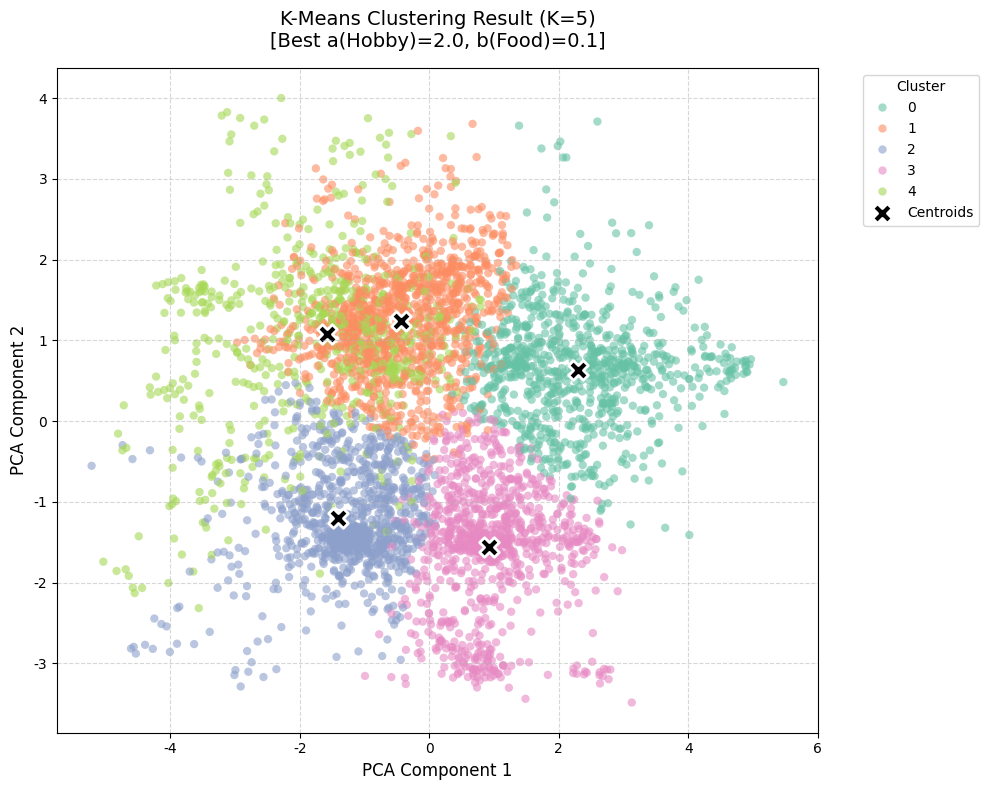

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

# 1. 최적의 가중치를 적용하여 최종 데이터 결합
final_combined = BEST_A * np_hobby_v + BEST_B * np_food_v

# 2. 최적의 가중치와 K로 최종 모델 학습 및 라벨 예측
final_kmeans = MiniBatchKMeans(
    n_clusters=FIXED_K, random_state=42, n_init=5, batch_size=4096
)
final_labels = final_kmeans.fit_predict(final_combined)
centroids = final_kmeans.cluster_centers_

# 3. 시각화를 위한 2차원 PCA 차원 축소
pca = PCA(n_components=2, random_state=42)

# 데이터와 중심점을 동일한 PCA 공간으로 변환
all_data_reduced = pca.fit_transform(
    np.vstack([final_combined, centroids])
)  # 중심점까지 한번에 변환

data_reduced = all_data_reduced[:-FIXED_K]  # 데이터 부분
centroids_reduced = all_data_reduced[-FIXED_K:]  # 중심점 부분

# 4. 맷플롯립 한글 깨짐 방지 설정 (필요시 사용)
plt.rcParams["font.family"] = "Malgun Gothic"  # 윈도우: Malgun Gothic, 맥: AppleGothic
plt.rcParams["axes.unicode_minus"] = False

# 5. 산점도 그리기
plt.figure(figsize=(10, 8))

# 각 클러스터별로 색상을 다르게 하여 산점도 작성
sns.scatterplot(
    x=data_reduced[:, 0],
    y=data_reduced[:, 1],
    hue=final_labels,
    palette="Set2",
    alpha=0.6,
    edgecolor="none",
)

# 클러스터 중심점(Centroids) 표시
plt.scatter(
    centroids_reduced[:, 0],
    centroids_reduced[:, 1],
    marker="X",
    s=200,
    linewidths=2,
    color="black",
    edgecolors="white",
    label="Centroids",
)

# 그래프 꾸미기
plt.title(
    f"K-Means Clustering Result (K={FIXED_K})\n[Best a(Hobby)={BEST_A:.1f}, b(Food)={BEST_B:.1f}]",
    fontsize=14,
    pad=15,
)
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## STEP 6. 전체 소비가치 분포 생성 → Google Drive 저장

- 10,000건 청크 단위 처리 → 로컬 체크포인트 parquet
- **10청크(100,000건)마다** Drive에 중간 업로드 (중단 복구 보험)
- 전체 완료 후 병합 → 최종 parquet을 Drive에 저장

In [23]:
# ── Drive 중간 업로드 주기 ────────────────────────────────────────────────────
GDRIVE_UPLOAD_EVERY_N_CHUNKS = 2


def load_progress() -> int:
    if PROGRESS_FILE.exists():
        return json.loads(PROGRESS_FILE.read_text())["last_chunk"]
    return -1


def save_progress(chunk_idx: int) -> None:
    PROGRESS_FILE.write_text(json.dumps({"last_chunk": chunk_idx}))


def process_chunk(
    chunk_df, culinary_scaler, model,
    hobby_mat, hobby_val_mat,
    hobby_weight_a: float,   # 취미 가중치 (절대값)
    culinary_weight_b: float  # 식소비 가중치 (절대값)
) -> pd.DataFrame:
    culinary_texts = chunk_df['culinary_persona'].tolist()
    hobby_texts    = chunk_df['hobbies_and_interests_list'].tolist()
    ids            = chunk_df['persona_id'].tolist()

    food_scores  = culinary_scaler.score_batch(culinary_texts, batch_size=FINAL_BATCH_SIZE)
    hobby_scores = score_hobby_batch_matrix(hobby_texts, model, hobby_mat, hobby_val_mat)

    hobby_valid = (hobby_scores.sum(axis=1, keepdims=True) > 0).astype(np.float32)

    # a·b 절대값 가중치 결합
    combined = hobby_weight_a * hobby_valid * hobby_scores \
             + culinary_weight_b * food_scores

    # 스케일 정규화 : 두 가중치 합으로 나눠 범위 유지
    denom = hobby_weight_a * hobby_valid + culinary_weight_b
    final_scores = combined / (denom + 1e-9)

    result = pd.DataFrame(np.round(final_scores, 4), columns=VALUE_COLS)
    result.insert(0, 'persona_id', ids)
    return result


# ── 청크 처리 ─────────────────────────────────────────────────────────────────
total       = len(df_raw)
n_chunks    = (total + CHUNK_SIZE - 1) // CHUNK_SIZE
start_chunk = load_progress() + 1
chunk_files = sorted(CHECKPOINT_DIR.glob("chunk_*.parquet"))

print(f"[STEP 6] 전체 {total:,}건 처리 시작")
print(f"  청크 크기  : {CHUNK_SIZE:,}  |  총 청크: {n_chunks}  |  시작 청크: {start_chunk}")
print(f"  취미 가중치: {BEST_A:.1f}  |  Drive 업로드 주기: 매 {GDRIVE_UPLOAD_EVERY_N_CHUNKS}청크")

for chunk_idx in tqdm(range(start_chunk, n_chunks), desc="청크 처리", initial=start_chunk, total=n_chunks):
    start = chunk_idx * CHUNK_SIZE
    end   = min(start + CHUNK_SIZE, total)

    chunk_df = df_raw.iloc[start:end].reset_index(drop=True)
    result_df = process_chunk(
        chunk_df, culinary_scaler,
        embed_model, hobby_mat, hobby_val_mat, BEST_A, BEST_B
    )

    chunk_path = CHECKPOINT_DIR / f"chunk_{chunk_idx:04d}.parquet"
    result_df.to_parquet(chunk_path, index=False)
    chunk_files.append(chunk_path)
    save_progress(chunk_idx)

    if (chunk_idx + 1) % GDRIVE_UPLOAD_EVERY_N_CHUNKS == 0:
        upload_to_gdrive(chunk_path, GDRIVE_FOLDER_ID, drive)

print("\n모든 청크 처리 완료.")


[STEP 6] 전체 8,042건 처리 시작
  청크 크기  : 10,000  |  총 청크: 1  |  시작 청크: 0
  취미 가중치: 2.0  |  Drive 업로드 주기: 매 2청크


청크 처리:   0%|          | 0/1 [00:00<?, ?it/s]


모든 청크 처리 완료.


In [24]:
# ── 청크 병합 → 최종 Parquet 저장 & Drive 업로드 ─────────────────────────────
print("[STEP 6] 청크 병합 중...")

all_chunks = sorted(CHECKPOINT_DIR.glob("chunk_*.parquet"))
final_df   = pd.concat(
    [pd.read_parquet(p) for p in tqdm(all_chunks, desc="병합")],
    ignore_index=True
)
final_df.to_parquet(FINAL_PARQUET, index=False)

print(f"\n로컬 저장 완료: {FINAL_PARQUET}")
print(f"  행 수    : {len(final_df):,}건")
print(f"  컬럼     : {list(final_df.columns)}")
print(f"  파일 크기: {FINAL_PARQUET.stat().st_size / 1024**2:.1f} MB")

# Google Drive 최종 업로드
final_url = upload_to_gdrive(FINAL_PARQUET, GDRIVE_FOLDER_ID, drive)
print(f"\n 최종 파일 Drive URL: {final_url}")

print("\n[요약 통계]")
print(final_df[VALUE_COLS].describe().round(3).to_string())

[STEP 6] 청크 병합 중...


병합:   0%|          | 0/1 [00:00<?, ?it/s]


로컬 저장 완료: outputs/nemotron_value_scores_1M.parquet
  행 수    : 8,042건
  컬럼     : ['persona_id', 'functional', 'emotional', 'social', 'epistemic', 'ethical']
  파일 크기: 0.5 MB
[덮어쓰기] nemotron_value_scores_1M.parquet
업로드 완료: https://drive.google.com/file/d/1MsoRfNvGZBmhMOdAX80c1GjlX0P4U-lA/view

 최종 파일 Drive URL: https://drive.google.com/file/d/1MsoRfNvGZBmhMOdAX80c1GjlX0P4U-lA/view

[요약 통계]
       functional  emotional    social  epistemic   ethical
count    8042.000   8042.000  8042.000   8042.000  8042.000
mean        3.581      4.646     3.640      3.228     2.845
std         0.704      0.653     0.757      0.973     0.903
min         0.000      0.000     0.000      0.000     0.000
25%         3.250      4.611     3.183      2.847     2.285
50%         3.674      4.815     3.763      3.386     2.820
75%         3.959      4.932     4.086      3.907     3.343
max         6.000      6.000     6.000      5.496     6.000


In [25]:
# ── 결과 미리보기 ─────────────────────────────────────────────────────────────
print("[상위 5건 미리보기]")
print(final_df.head().to_string(index=False))

print("\n[가치별 분포 (전체 평균)]")
means = final_df[VALUE_COLS].mean().sort_values(ascending=False)
for col, val in means.items():
    bar = '█' * int(val * 2)
    print(f"  {col:<12}: {val:.3f}점  {bar}")

[상위 5건 미리보기]
                      persona_id  functional  emotional  social  epistemic  ethical
f7c1309120bf4762b0ceb29e842ebe51      3.6929     4.7724  3.9358     4.1923   2.6658
fc96d55750ff46d59259974507062620      3.8616     4.9309  3.7385     2.8854   2.9949
1c0f3c5d507c43d4b8cd9db6658b5790      3.8019     4.8291  3.7005     4.2287   3.1859
13557e179d0944abb1691c1db23e0713      3.5323     4.9332  4.0058     3.1124   2.0806
999d45b7626a418b8c0cd023839e32cb      3.9555     4.9436  3.0095     3.9023   2.0595

[가치별 분포 (전체 평균)]
  emotional   : 4.646점  █████████
  social      : 3.640점  ███████
  functional  : 3.581점  ███████
  epistemic   : 3.228점  ██████
  ethical     : 2.845점  █████


---
## STEP 7. 군집 분류 → type1 / type2 CSV

사전 정의된 군집 중심점과 각 페르소나의 5대 가치 점수 벡터 간
**코사인 유사도**를 계산해 가장 가까운 군집 2개를 type1, type2로 할당합니다.

군집 중심점은 논문에 정의된 중심점에서 데이터의 스케일에 맞게 조정하여 사용합니다.

전체 코사인 유사도 분포도를 확인후 적절한 임계값을 정해 그 밑에 유사도는 노이즈로 간주합니다.

In [26]:
# 한글 폰트 설치
!apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 등록 및 캐시 업데이트
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (53.1 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


[STEP 7] 스케일 재조정된 군집 중심점 (현실 데이터 반영)
  사회적 소비: [np.float32(3.47), np.float32(4.86), np.float32(4.11), np.float32(3.1), np.float32(2.8)]
  적극적 소비: [np.float32(4.45), np.float32(5.63), np.float32(4.77), np.float32(4.69), np.float32(4.2)]
  자기 중심적: [np.float32(4.19), np.float32(5.56), np.float32(2.76), np.float32(4.16), np.float32(1.67)]
  윤리적 소비: [np.float32(4.64), np.float32(5.06), np.float32(2.5), np.float32(1.77), np.float32(3.4)]
  소극적 실속: [np.float32(2.52), np.float32(3.67), np.float32(2.8), np.float32(2.34), np.float32(1.49)]


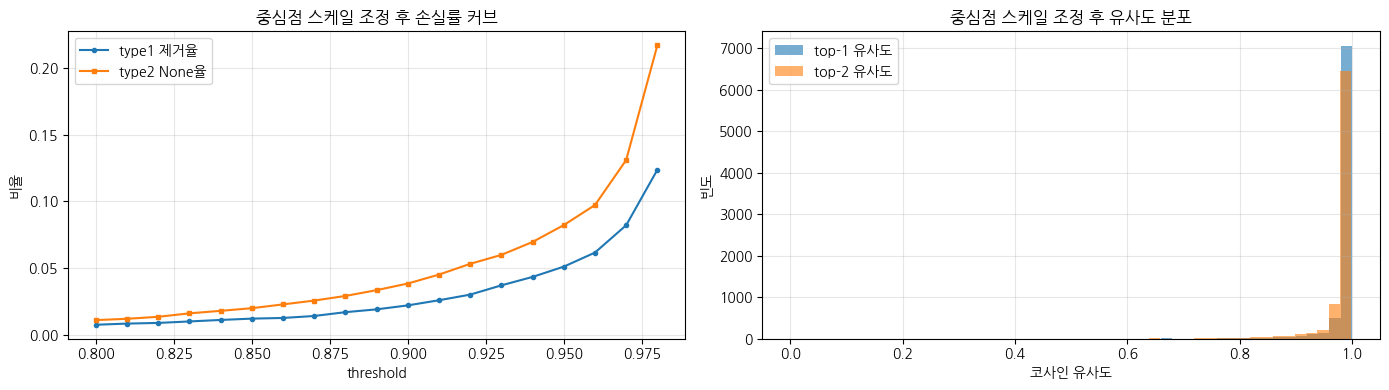


 threshold |    type1 제거율 |    type1 제거 건수 |  type2 None율
----------------------------------------------------------
      0.80 |        0.7% |             59 |        1.1%
      0.81 |        0.8% |             66 |        1.2%
      0.82 |        0.9% |             70 |        1.3%
      0.83 |        1.0% |             79 |        1.6%
      0.84 |        1.1% |             88 |        1.8%
      0.85 |        1.2% |             96 |        2.0%
      0.86 |        1.2% |            100 |        2.3%
      0.87 |        1.4% |            112 |        2.5%
      0.88 |        1.7% |            135 |        2.9%
      0.89 |        1.9% |            152 |        3.3%
      0.90 |        2.2% |            176 |        3.8%
      0.91 |        2.6% |            207 |        4.5%
      0.92 |        3.0% |            241 |        5.3%
      0.93 |        3.7% |            297 |        6.0%
      0.94 |        4.3% |            348 |        7.0%
      0.95 |        5.1% |            410 

In [27]:
# ── [STEP 7-1] 원본 데이터 스케일 분석 ──
# VALUE_COLS 순서: functional, emotional, social, epistemic, ethical
raw_data = final_df[VALUE_COLS].values.astype(np.float32)

# 실제 데이터의 가치별 평균과 표준편차 추출
data_means = np.mean(raw_data, axis=0)  # [3.581, 4.646, 3.640, 3.228, 2.845]
data_stds = np.std(raw_data, axis=0)

# ── [STEP 7-2] 군집 중심점 비율 유지형 스케일 다운 (MinMax 기반 매핑) ──
# 기존 기획된 중심점 (현실 데이터에 비해 스케일이 매우 큼)
ORIGINAL_CENTROIDS = {
    "사회적 소비": [5.70, 5.25, 4.36, 4.16, 4.28],
    "적극적 소비": [6.18, 6.11, 5.15, 5.52, 5.05],
    "자기 중심적": [6.05, 6.04, 2.77, 5.07, 3.66],
    "윤리적 소비": [6.27, 5.48, 2.47, 3.02, 4.61],
    "소극적 실속": [5.24, 3.91, 2.82, 3.51, 3.56],
}

orig_mat = np.array(list(ORIGINAL_CENTROIDS.values()), dtype=np.float32)

# 각 컬럼(가치)별로 오리지널 중심점의 최소/최대값 구하기
orig_min = orig_mat.min(axis=0)
orig_max = orig_mat.max(axis=0)

# 현실 데이터 기반의 새로운 타겟 범위 설정
# 실제 데이터 평균을 중심으로 ±1.5 표준편차 수준의 현실적인 바운더리를 생성합니다.
target_min = np.clip(data_means - 1.5 * data_stds, 1.0, 7.0)
target_max = np.clip(data_means + 1.5 * data_stds, 1.0, 7.0)

# 스케일 변환 공식 적용: 오리지널 비율을 유지한 채 현실 스케일 범위로 매핑
# (X - orig_min) / (orig_max - orig_min) * (target_max - target_min) + target_min
denom = orig_max - orig_min
denom = np.where(denom == 0, 1e-9, denom)  # 0 나누기 방지

rescaled_mat = ((orig_mat - orig_min) / denom) * (
    target_max - target_min
) + target_min

# 조정된 중심점을 딕셔너리로 재조립
CLUSTER_NAMES = list(ORIGINAL_CENTROIDS.keys())
CLUSTER_CENTROIDS_RESCALED = {
    name: list(np.round(rescaled_mat[i], 2))
    for i, name in enumerate(CLUSTER_NAMES)
}

print("[STEP 7] 스케일 재조정된 군집 중심점 (현실 데이터 반영)")
for name, vec in CLUSTER_CENTROIDS_RESCALED.items():
    print(f"  {name}: {vec}")

# ── [STEP 7-3] 새 스케일 기준 유사도 분포 확인 ──
# 내적(코사인 유사도)을 위한 L2 정규화
centroid_norm = rescaled_mat / (
    np.linalg.norm(rescaled_mat, axis=1, keepdims=True) + 1e-9
)
data_norm = raw_data / (np.linalg.norm(raw_data, axis=1, keepdims=True) + 1e-9)

# 유사도 계산
_sim_all = data_norm @ centroid_norm.T
top1_sim = _sim_all.max(axis=1)
top2_sim = np.sort(_sim_all, axis=1)[:, -2]

# 임계값 범위 설정
thresholds = np.arange(0.80, 0.99, 0.01)
loss_type1 = [(top1_sim < t).mean() for t in thresholds]
loss_type2 = [(top2_sim < t).mean() for t in thresholds]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(
    thresholds, loss_type1, label="type1 제거율", marker="o", markersize=3
)
axes[0].plot(
    thresholds, loss_type2, label="type2 None율", marker="s", markersize=3
)
axes[0].set_xlabel("threshold")
axes[0].set_ylabel("비율")
axes[0].set_title("중심점 스케일 조정 후 손실률 커브")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(top1_sim, bins=50, alpha=0.6, label="top-1 유사도")
axes[1].hist(top2_sim, bins=50, alpha=0.6, label="top-2 유사도")
axes[1].set_xlabel("코사인 유사도")
axes[1].set_ylabel("빈도")
axes[1].set_title("중심점 스케일 조정 후 유사도 분포")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 수치 요약
print(
    f"\n{'threshold':>10} | {'type1 제거율':>12} | {'type1 제거 건수':>14} | {'type2 None율':>12}"
)
print("-" * 58)
for t, l1, l2 in zip(thresholds, loss_type1, loss_type2):
    print(
        f"{t:>10.2f} | {l1:>11.1%} | {int(l1 * len(final_df)):>14,} | {l2:>11.1%}"
    )

어느 군집에도 닮지 않은 분포 제거

In [31]:
# ── [STEP 7-4] 최종 임계값 확정 및 군집 할당 ──

# 앞서 스케일 다운된 centroid_norm을 그대로 사용합니다.
# 데이터 역시 StandardScaler 변환 전의 원본(raw_data)을 그대로 사용하므로 안전합니다.

FINAL_SIM_THRESHOLD = 0.95  # 위의 표를 바탕으로 설정

print(
    f"\n[최종 단계] 임계값 {FINAL_SIM_THRESHOLD} 적용 및 페르소나 매핑 시작..."
)

def assign_clusters_top2(
    score_df,
    centroid_norm: np.ndarray,
    cluster_names: list,
    value_cols: list = None,
    sim_threshold: float = SIM_THRESHOLD,
    chunk_size: int = 50_000,
):
    """
    각 페르소나의 가치 점수 벡터와 군집 중심점 간 코사인 유사도를 계산해
    상위 2개 군집을 type1, type2로 반환합니다.

    type1 유사도 < sim_threshold  →  해당 행을 결과에서 제거 (데이터풀 제외)
    type2 유사도 < sim_threshold  →  type2 = None (행은 유지)

    Parameters
    ----------
    score_df       : final_df (persona_id + VALUE_COLS)
    centroid_norm  : L2 정규화된 군집 중심점 행렬 (K, 5)
    cluster_names  : 군집 이름 리스트 (K,)
    sim_threshold  : type1 제거 및 type2 None 처리 기준 코사인 유사도

    Returns
    -------
    DataFrame: [uuid, type1, type2, top1_sim, top2_sim]
        - type1이 threshold 미달인 행은 제거됨
        - type2가 threshold 미달이면 None
    """
    if value_cols is None:
        value_cols = VALUE_COLS

    score_mat = score_df[value_cols].values.astype(np.float32)   # (N, 5)

    uuid_list  = []
    type1_list = []
    type2_list = []
    top1_sim_list = []
    top2_sim_list = []

    for start in tqdm(range(0, len(score_mat), chunk_size), desc="군집 분류"):
        chunk = score_mat[start : start + chunk_size]             # (B, 5)

        # L2 정규화
        chunk_norm = chunk / (np.linalg.norm(chunk, axis=1, keepdims=True) + 1e-9)

        # 코사인 유사도: (B, K)
        sim = chunk_norm @ centroid_norm.T

        # Top-2 인덱스 (내림차순)
        top2_idx = np.argsort(sim, axis=1)[:, -2:][:, ::-1]      # (B, 2)

        top1_s = sim[np.arange(len(sim)), top2_idx[:, 0]]         # (B,)
        top2_s = sim[np.arange(len(sim)), top2_idx[:, 1]]         # (B,)

        chunk_ids = score_df['persona_id'].values[start : start + chunk_size]

        for i in range(len(sim)):
            # type1 미달 → 행 전체 제거
            if top1_s[i] < sim_threshold:
                continue

            uuid_list.append(chunk_ids[i])
            type1_list.append(cluster_names[top2_idx[i, 0]])
            top1_sim_list.append(float(top1_s[i]))

            # type2 미달 → None 처리 (행은 유지)
            if top2_s[i] < sim_threshold:
                type2_list.append(None)
                top2_sim_list.append(float(top2_s[i]))
            else:
                type2_list.append(cluster_names[top2_idx[i, 1]])
                top2_sim_list.append(float(top2_s[i]))

    return pd.DataFrame({
        'uuid':     uuid_list,
        'type1':    type1_list,
        'type2':    type2_list,
        'top1_sim': top1_sim_list,
        'top2_sim': top2_sim_list,
    })

# 기존 원본 데이터(final_df)와 변환된 중심점(centroid_norm) 전달
final_cluster_df = assign_clusters_top2(
    score_df=final_df,
    centroid_norm=centroid_norm,  # 스케일 조정 후 L2 정규화된 행렬
    cluster_names=CLUSTER_NAMES,
    value_cols=VALUE_COLS,
    sim_threshold=FINAL_SIM_THRESHOLD,
)

# ── 필터링 결과 최종 요약 ─────────────────────────────────────────────────────
n_total = len(final_df)
n_retained = len(final_cluster_df)
n_removed = n_total - n_retained
n_type2_none = final_cluster_df["type2"].isna().sum()

print(f"\n{'='*50}")
print(f"  ▶ 최종 반영 결과 요약 (THRESHOLD = {FINAL_SIM_THRESHOLD})")
print(f"{'='*50}")
print(f"  모개체 유저 수    : {n_total:>10,}건")
print(
    f"  페르소나 매칭 유저 : {n_retained:>10,}건  ({n_retained/n_total:.1%})"
)
print(
    f"  노이즈 제거 유저  : {n_removed:>10,}건  ({n_removed/n_total:.1%})"
)
print(
    f"  단일 성향 유저(Type2=None) : {n_type2_none:>10,}건  ({n_type2_none/n_retained:.1%})"
)
print(
    f"  복합 성향 유저(Type2 존재)  : {n_retained - n_type2_none:>10,}건  ({(n_retained - n_type2_none)/n_retained:.1%})"
)
print(f"{'='*50}")

print("\n[주성향(Type 1) 탑재 유저 분포]")
print(final_cluster_df["type1"].value_counts().to_string())

# 이후 파이프라인에서 쓰기 위해 데이터프레임 확인
# final_cluster_df.head()


[최종 단계] 임계값 0.95 적용 및 페르소나 매핑 시작...


군집 분류:   0%|          | 0/1 [00:00<?, ?it/s]


  ▶ 최종 반영 결과 요약 (THRESHOLD = 0.95)
  모개체 유저 수    :      8,042건
  페르소나 매칭 유저 :      7,632건  (94.9%)
  노이즈 제거 유저  :        410건  (5.1%)
  단일 성향 유저(Type2=None) :        251건  (3.3%)
  복합 성향 유저(Type2 존재)  :      7,381건  (96.7%)

[주성향(Type 1) 탑재 유저 분포]
type1
적극적 소비    3024
사회적 소비    2183
소극적 실속    1583
윤리적 소비     566
자기 중심적     276


In [33]:
# ── CSV 저장 & Google Drive 업로드 ───────────────────────────────────────────
CLUSTER_CSV = LOCAL_DIR / "nemotron_cluster_types.csv"

final_cluster_df.to_csv(CLUSTER_CSV, index=False, encoding='utf-8-sig')
print(f"로컬 저장: {CLUSTER_CSV}")
print(f"  행 수  : {len(final_cluster_df):,}건")
print(f"  컬럼   : {list(final_cluster_df.columns)}")
print("\n[상위 10건 미리보기]")
print(final_cluster_df.head(10).to_string(index=False))

# Google Drive 업로드
cluster_url = upload_to_gdrive(CLUSTER_CSV, GDRIVE_FOLDER_ID, drive)
print(f"\n   Drive URL: {cluster_url}")

로컬 저장: outputs/nemotron_cluster_types.csv
  행 수  : 7,632건
  컬럼   : ['uuid', 'type1', 'type2', 'top1_sim', 'top2_sim']

[상위 10건 미리보기]
                            uuid  type1  type2  top1_sim  top2_sim
f7c1309120bf4762b0ceb29e842ebe51 적극적 소비 사회적 소비  0.995073  0.992159
fc96d55750ff46d59259974507062620 사회적 소비 적극적 소비  0.997310  0.992028
1c0f3c5d507c43d4b8cd9db6658b5790 적극적 소비 사회적 소비  0.998060  0.990654
13557e179d0944abb1691c1db23e0713 소극적 실속 사회적 소비  0.999616  0.996327
999d45b7626a418b8c0cd023839e32cb 자기 중심적 소극적 실속  0.996414  0.989597
f4342aa625ef4c4d974ac696bb1feecf 소극적 실속 자기 중심적  0.983988  0.974263
8aaf90283b4f424f97e1f0830445fc48 사회적 소비 적극적 소비  0.996577  0.991319
541946b2aa5e4072a72cd8f904214271 적극적 소비 사회적 소비  0.993695  0.987522
edff69bc56814e088b5eda29f846a76c 자기 중심적 소극적 실속  0.995741  0.989864
986b6f6c212146a086ec8558a42720d3 적극적 소비 사회적 소비  0.993115  0.987599
[덮어쓰기] nemotron_cluster_types.csv
업로드 완료: https://drive.google.com/file/d/11RqJnykthWrgOi-uLiUOpXEkKeSVkJeW/view

   Drive URL: ht